In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the CSV files
train_params = pd.read_csv('train_parameters.csv')
stations = pd.read_csv('stations.csv')
curves = pd.read_csv('curves.csv')
gradients = pd.read_csv('gradients.csv')
speed_restrictions = pd.read_csv('sr.csv')

# Load the train parameters CSV file
train_params = pd.read_csv('train_parameters.csv')

#print(speed_restrictions.columns)
#print(curves.columns)


In [3]:
# Convert the 'Value' column to a dictionary for easy access
train_params_dict = pd.Series(train_params.Value.values, index=train_params.Parameter).to_dict()

# Create a dictionary to map radius to speed restriction
speed_limit_dict = pd.Series(speed_restrictions.Speed_Limit.values, index=speed_restrictions.Radius).to_dict()

# Extract values from the dictionary
acceleration = float(train_params_dict['Acceleration_rate'])
braking = float(train_params_dict['Braking_rate'])
max_speed = float(train_params_dict['Maximum_speed'])  # Assuming the speed is in km/h, convert to m/s
static_friction = float(train_params_dict['Static_friction'])
rolling_resistance = float(train_params_dict['Rolling_resistance'])
air_resistance = float(train_params_dict['Air_resistance'])
mass = float(train_params_dict['Mass'])  # Train mass in tons
power = float(train_params_dict['Power'])  # Power in kW

# Convert max_speed from km/h to m/s
max_speed = max_speed * 1000 / 3600

#print(f'static_friction:{static_friction},mass:{mass}')


In [4]:
# Function to accelerate the train
def accelerate(speed, acceleration, max_speed, time_step):
    if speed + acceleration * time_step > max_speed:
        speed = max_speed
    else:
        speed += acceleration * time_step
    return speed


In [5]:
# Function to brake the train
def brake(speed, braking, time_step):
    if speed - braking * time_step < 0:
        speed = 0
    else:
        speed -= braking * time_step
    return speed


In [6]:
def coast(speed, mass, static_friction, rolling_resistance, air_resistance, time_step=1):
    """
    Calculate the reduced speed during coasting due to friction forces.

    Parameters:
    - speed (float): Current speed of the train (m/s).
    - mass (float): Mass of the train (in tons).
    - static_friction (float): Static friction coefficient (N/ton).
    - rolling_resistance (float): Rolling resistance coefficient (N/ton/m/s).
    - air_resistance (float): Air resistance coefficient (N/ton/m^2/s^2).
    - time_step (float): Time over which to calculate the speed reduction (seconds). Default is 1 second.

    Returns:
    - float: The new reduced speed after applying friction forces.
    """

    if (no_coasting):
        return speed
        
    # Convert mass from tons to kg (1 ton = 1000 kg)
    mass_kg = mass * 1000

    # Calculate the total resistance (Davis equation)
    resistance = (static_friction + rolling_resistance * speed + air_resistance * speed**2) * mass

    # Calculate deceleration due to resistance (force/mass)
    deceleration = resistance / mass_kg  # in m/s²

    # Calculate the new speed after deceleration
    new_speed = speed - deceleration * time_step

    # Ensure the speed doesn't go below 0
    if new_speed < 0:
        new_speed = 0

    return new_speed

In [7]:
# Function to find the speed restriction at a given distance
def get_speed_restriction(distance):
    # Loop through each curve
    for i in range(len(curves)):
        start = curves.iloc[i]['Start']
        end = curves.iloc[i]['End']
        radius = curves.iloc[i]['Radius']
        
        # Check if the current distance falls within the curve zone
        if start <= distance <= end:
            # Return the speed restriction for the corresponding radius
            return speed_limit_dict.get(radius, None)  * 1000 / 3600 # Returns None if radius not found
    return None  # No speed restriction if distance is outside curve zones


In [8]:
# Extract the chainage and station names
station_chainages = stations['Chainage'].values
station_names = stations['Station_Name'].values
#print(len(station_names))

# Calculate distances between consecutive stations
distances_between_stations = [station_chainages[i+1] - station_chainages[i] for i in range(len(station_chainages)-1)]

# Example of processing station data
#print("Stations and Chainages:")
#for i in range(len(station_chainages)):
#    print(f"Station {station_names[i]} at chainage {station_chainages[i]} meters")

#print("\nDistances between stations:")
#for i in range(len(distances_between_stations)):
#    print(f"Distance between {station_names[i]} and {station_names[i+1]}: {distances_between_stations[i]} meters")



In [9]:
# Initialize simulation variables
time = 0
speed = 0
distance = 0
covered_distance = 0
time_log = []
speed_log = []
no_coasting = False

# Simulate the movement from station to station
for i in range(len(station_names)-1):
    start_station = station_chainages[i]
    end_station = station_chainages[i+1]
    segment_distance = end_station - start_station
    #print(f'Next Station: {segment_distance} Distance Covered: {covered_distance} Reset:{distance}')
    
    # Accelerate after leaving the station
    while distance < segment_distance:  # Accelerate
        speed = accelerate(speed, acceleration, max_speed, time_step=1)
        distance += speed
        #print(f'Speed:{speed} Distance:{distance}')
        if (speed >= max_speed):
            break
        else:
            time += 1
        time_log.append(time/60)
        speed_log.append(speed * 18 / 5)

    # Coast until speed drops to 80% of the max speed
    while distance < (segment_distance - max_speed**2/2/braking):  # Coasting
        #print('coast')
        if speed > 0.8 * max_speed:
            speed = coast(speed, mass, static_friction, rolling_resistance, air_resistance, time_step=1)  # Coasting deceleration, assumed to be small
        else:
            speed = accelerate(speed, acceleration, max_speed, time_step=1)
        speed_limit = get_speed_restriction(covered_distance + distance)
        if speed_limit:
            speed = speed_limit
        distance += speed
        speed_check = coast(speed, mass, static_friction, rolling_resistance, air_resistance, time_step=1)
        #print(f'Check:{speed_check}, speed:{speed}')
        #print(f'Speed:{speed} Distance:{distance}')
        time += 1
        time_log.append(time/60)
        speed_log.append(speed * 18 / 5)
    
    # Brake before reaching the station
    while distance < segment_distance:  # Braking
        speed = brake(speed, braking, time_step=1)
        distance += speed
        #print(f'Speed:{speed} Distance:{distance}')
        if (speed == 0):
            break
        else:
            time += 1
        time_log.append(time/60)
        speed_log.append(speed * 18 / 5)

    # Stop at the station for 30 seconds
    for _ in range(30):
        time += 1
        time_log.append(time/60)
        speed_log.append(0)

    covered_distance += segment_distance
    distance = 0
    speed = 0

#print(f'time:{time_log}')
#print(f'speed:{speed_log}')

In [10]:
# Calculate the average speed
total_distance = station_chainages[-1] - station_chainages[0]
average_speed = total_distance / time
print(f"A total distance of {total_distance/1000:.2f} Km was covered in {time/60:.2f} minutes.")
print(f"Average speed for the trip was: {average_speed*18/5:.2f} km/hr")


A total distance of 35.78 Km was covered in 41.62 minutes.
Average speed for the trip was: 51.58 km/hr


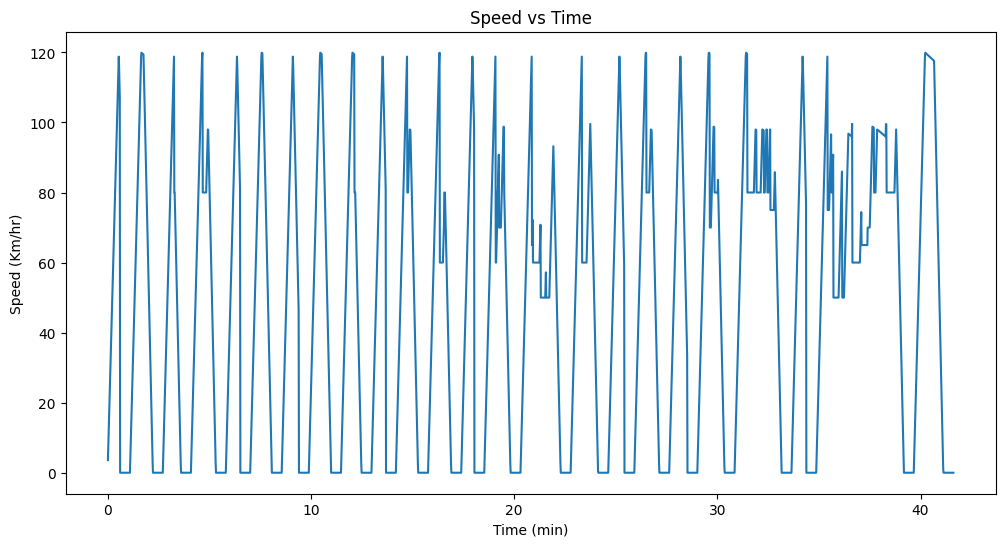

In [11]:
# Plot the speed vs time graph
fig = plt.figure(figsize=(12, 6))

plt.plot(time_log, speed_log)
plt.title('Speed vs Time')
plt.xlabel('Time (min)')
plt.ylabel('Speed (Km/hr)')
plt.show()

